<a href="https://colab.research.google.com/github/ellieyeonhee/FineDust_prediction/blob/main/FineDust_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Collection**

In [ ]:
import urllib.request
import json
from pandas import json_normalize
from urllib.parse import urlencode, quote_plus, unquote
# Load the uploaded CSV file and filter rows where the column 'Section' has the value 'Average'
# Let's load the newly uploaded CSV file and filter the rows where the column '구분' has the value '평균'.
import pandas as pd

# Load the CSV file
file_path = '/content/drive/MyDrive/ML_ass2/Seoul Hourly air quality_20221231/Seoul Air Quality_2012-2015.csv'

# Try loading the file using the possible encoding that could handle Korean characters (euc-kr or cp949)
df = pd.read_csv(file_path)

# Filter the data where the '구분(Section)' column is '평균(Average)'
filtered_df = df[df['구분'] == '평균']

# Display the filtered data
filtered_df.to_excel('filtered_2012-2015.xlsx')

**Data Merging and Sorting**

In [ ]:
import pandas as pd

# File paths for all 4 Excel files
file_paths = [
    '/content/drive/MyDrive/ML_ass2/Filtered dataset/filtered_2012-2015.xlsx',
    '/content/drive/MyDrive/ML_ass2/Filtered dataset/filtered_2016-2019.xlsx',
    '/content/drive/MyDrive/ML_ass2/Filtered dataset/filtered_2020-2021.xlsx',
    '/content/drive/MyDrive/ML_ass2/Filtered dataset/filtered_2022.xlsx'
]

# Load all Excel files into pandas DataFrames
dfs = [pd.read_excel(file) for file in file_paths]

# Concatenate all the DataFrames into a single DataFrame
merged_df = pd.concat(dfs, ignore_index=True)

# Convert the 'Date' column to datetime format, letting Pandas infer the format automatically
# Replace 'Date' with the actual column name if necessary
merged_df['Date'] = pd.to_datetime(merged_df['Date'], infer_datetime_format=True)

# Sort the DataFrame by the 'Date' column in ascending order
sorted_df = merged_df.sort_values(by='Date', ascending=True)

# Save the merged and sorted DataFrame to a new Excel file
output_file = 'Transformed_data.xlsx'
sorted_df.to_excel(output_file, index=False)

print(f"Merged and sorted data has been saved to {output_file}.")


<ipython-input-11-c30ad0bf0c53>:19: UserWarning:

The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.



Merged and sorted data has been saved to Transformed_data.xlsx.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/ML_ass2/Filtered dataset/Transformed_data.xlsx"

# Load the Excel file into a pandas DataFrame
df = pd.read_excel(file_path)

print(df)


       Unnamed: 0                Date  PM10  PM2.5
0          907315 2012-01-01 00:00:00    80     55
1          907289 2012-01-01 01:00:00    79     54
2          907263 2012-01-01 02:00:00    81     54
3          907237 2012-01-01 03:00:00    82     56
4          907211 2012-01-01 04:00:00    84     58
...           ...                 ...   ...    ...
96425         104 2022-12-31 19:00:00    55     42
96426          78 2022-12-31 20:00:00    56     43
96427          52 2022-12-31 21:00:00    56     44
96428          26 2022-12-31 22:00:00    58     45
96429           0 2022-12-31 23:00:00    59     46

[96430 rows x 4 columns]


In [ ]:
import plotly.express as px

fig = px.line(df, x='Date', y='PM2.5')
fig.show()


In [ ]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['Date'], y=df['PM10'],
                    mode='lines',
                    name='PM10'))
fig.add_trace(go.Scatter(x=df['Date'], y=df['PM2.5'],
                    mode='lines',
                    name='PM2.5'))
fig.show()


# **Data Preprocessing**

**Check for missing values**

In [ ]:
import pandas as pd

# Load the data
data = pd.read_excel("/content/drive/MyDrive/ML_ass2/Filtered dataset/Transformed_data.xlsx")

# Summarise the dataset information
print(data.describe())

# Chect for missing value
print(data.isnull().sum())

# Print
print(data.head())


          Unnamed: 0                           Date          PM10  \
count   96430.000000                          96430  96430.000000   
mean   382240.194483  2017-07-01 23:50:05.512807168     41.406844   
min         0.000000            2012-01-01 00:00:00      3.000000   
25%    156032.000000            2014-10-01 11:15:00     23.000000   
50%    340991.500000            2017-07-02 00:30:00     35.000000   
75%    596475.000000            2020-04-01 11:45:00     52.000000   
max    911514.000000            2022-12-31 23:00:00    902.000000   
std    261558.966410                            NaN     30.897151   

              PM2.5  
count  96430.000000  
mean      22.948885  
min        1.000000  
25%       12.000000  
50%       19.000000  
75%       29.000000  
max      476.000000  
std       16.082864  
Unnamed: 0    0
Date          0
PM10          0
PM2.5         0
dtype: int64
   Unnamed: 0                Date  PM10  PM2.5
0      907315 2012-01-01 00:00:00    80     55
1      90

**Split the data**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Include all relevant feature columns in X, excluding the target column 'PM2.5'
X = df.drop(columns=['PM2.5'])
y = df['PM2.5']  # Target column

# Split into 70% training and the rest 30% (testing + validation)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# From the remaining 30%, split into 20% testing and 10% validation
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=(1/3), random_state=42)

# Convert the 'Date' column to datetime and extract features in-place (without extra variables)
for dataset in [X_train, X_val, X_test]:
    # Convert the 'Date' column to datetime if it's not already
    dataset['Date'] = pd.to_datetime(dataset['Date'])  # Replace 'Date' with your actual column name

    # Extract useful features from the 'Date' column
    dataset['Year'] = dataset['Date'].dt.year
    dataset['Month'] = dataset['Date'].dt.month
    dataset['Day'] = dataset['Date'].dt.day
    dataset['Hour'] = dataset['Date'].dt.hour  # If hourly data is important

    # Drop the original 'Date' column
    dataset.drop(columns=['Date'], inplace=True)

# Output the sizes of each dataset
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")


Training set: (67501, 6), (67501,)
Validation set: (9643, 6), (9643,)
Test set: (19286, 6), (19286,)


# **Model Implementation**

# **1 Random Forest Regression Model**

**Design Random Forest Regression model**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Model Architecture
rf_model = RandomForestRegressor(n_estimators=100,
                                 max_depth=10,
                                 min_samples_split=2,
                                 min_samples_leaf=1,
                                 random_state=42,
                                 n_jobs=-1)


**Train the model**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

#Train the model using the training data
rf_model.fit(X_train, y_train)

#Predict using the validation data
y_val_pred = rf_model.predict(X_val)


**Evaluation**

In [ ]:
#Evaluate the model performance on the validation set
mse = mean_squared_error(y_val, y_val_pred)
mae = mean_absolute_error(y_val, y_val_pred)

print(f'Validation Mean Squared Error: {mse}')
print(f'Validation Mean Absolute Error: {mae}')

#Test it on the test set:
y_test_pred = rf_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f'Test Mean Squared Error: {test_mse}')
print(f'Test Mean Absolute Error: {test_mae}')

Validation Mean Squared Error: 26.889441182227223
Validation Mean Absolute Error: 3.1779309840253727
Test Mean Squared Error: 46.168705164886276
Test Mean Absolute Error: 3.2538027275257893


# **2 LSTM Model**

**Data Preprocessing for LSTM model**

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np


# Data scaling (normalization)
scaler = MinMaxScaler()

# Apply scaling to the feature data
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Determine how many samples can be reshaped into timesteps
timesteps = 5
# Trimming the dataset so that it's divisible by the number of timesteps
train_trim = X_train_scaled.shape[0] - (X_train_scaled.shape[0] % timesteps)
val_trim = X_val_scaled.shape[0] - (X_val_scaled.shape[0] % timesteps)
test_trim = X_test_scaled.shape[0] - (X_test_scaled.shape[0] % timesteps)

# Trimming the datasets
X_train_trimmed = X_train_scaled[:train_trim]
X_val_trimmed = X_val_scaled[:val_trim]
X_test_trimmed = X_test_scaled[:test_trim]

# Reshape the data to 3D: (samples, timesteps, features)
X_train_reshaped = X_train_trimmed.reshape((train_trim // timesteps, timesteps, X_train_scaled.shape[1]))
X_val_reshaped = X_val_trimmed.reshape((val_trim // timesteps, timesteps, X_val_scaled.shape[1]))
X_test_reshaped = X_test_trimmed.reshape((test_trim // timesteps, timesteps, X_test_scaled.shape[1]))

# Convert y_train, y_val, and y_test from pandas Series to numpy array for reshaping
y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
y_test_np = y_test.to_numpy()

# Trimming the target variables to match the reshaped input
y_train_reshaped = y_train_np[:train_trim].reshape(-1, timesteps).mean(axis=1)
y_val_reshaped = y_val_np[:val_trim].reshape(-1, timesteps).mean(axis=1)
y_test_reshaped = y_test_np[:test_trim].reshape(-1, timesteps).mean(axis=1)


(67501, 1, 6)


**Build LSTM model**

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Build the LSTM model
model = Sequential()

# Add Input layer (with timesteps and features)
model.add(Input(shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))

# Add LSTM layers with 100 and 50 units
model.add(LSTM(100, return_sequences=True))
model.add(LSTM(50))

# Add Dropout to prevent overfitting
model.add(Dropout(0.3))

# Add Dense output layer (predicting a single value, such as PM2.5 or PM10)
model.add(Dense(1))

# Compile the model with Adam optimizer
opt = Adam(learning_rate=0.001)
model.compile(optimizer=opt, loss='mean_squared_error', metrics=['mae'])

# Add EarlyStopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

**Train the model**

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error



# Train the model using the reshaped data
model.fit(X_train_reshaped, y_train_reshaped, epochs=100, batch_size=64, validation_data=(X_val_reshaped, y_val_reshaped), callbacks=[early_stopping])



**Evaluation and Visualisation**

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Evaluate the model on the test set
y_test_pred = model.predict(X_test_reshaped)

# Calculate evaluation metrics
test_mse = mean_squared_error(y_test_reshaped, y_test_pred)
test_mae = mean_absolute_error(y_test_reshaped, y_test_pred)

print(f'Test Mean Squared Error: {test_mse}')
print(f'Test Mean Absolute Error: {test_mae}')


Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 309.8396 - mae: 15.0630 - val_loss: 76.4965 - val_mae: 6.5571
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 70.4371 - mae: 6.2032 - val_loss: 53.5758 - val_mae: 5.6172
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 57.6931 - mae: 5.7766 - val_loss: 52.3932 - val_mae: 5.6281
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 56.8024 - mae: 5.8176 - val_loss: 52.2849 - val_mae: 5.6412
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 57.8349 - mae: 5.9035 - val_loss: 52.3401 - val_mae: 5.6333
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 59.2634 - mae: 5.8345 - val_loss: 52.3286 - val_mae: 5.6346
Epoch 7/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 58.3299 - mae: 5.8848 - val_loss: 52.2852 - val_mae: 5.6409
Epoch 8/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 56.7513 - mae: 5.8116 - val_loss: 52.3307 - val_mae: 5.6342
Epoch 9/100
211/211 ━━

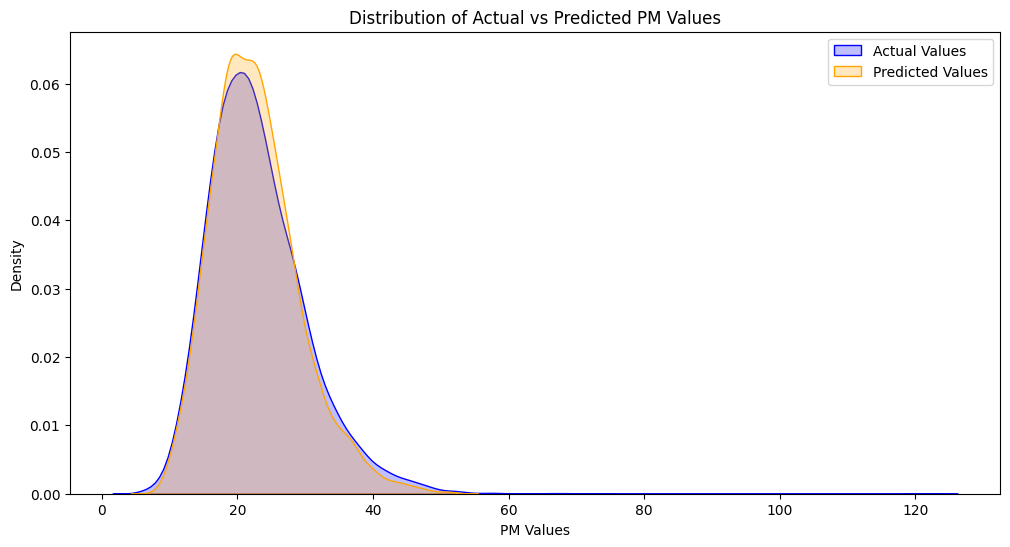

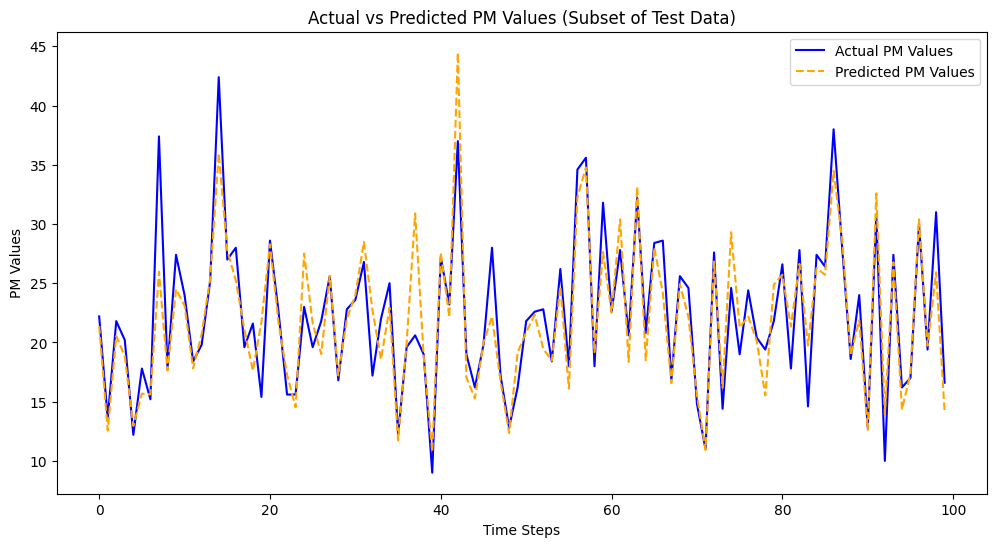

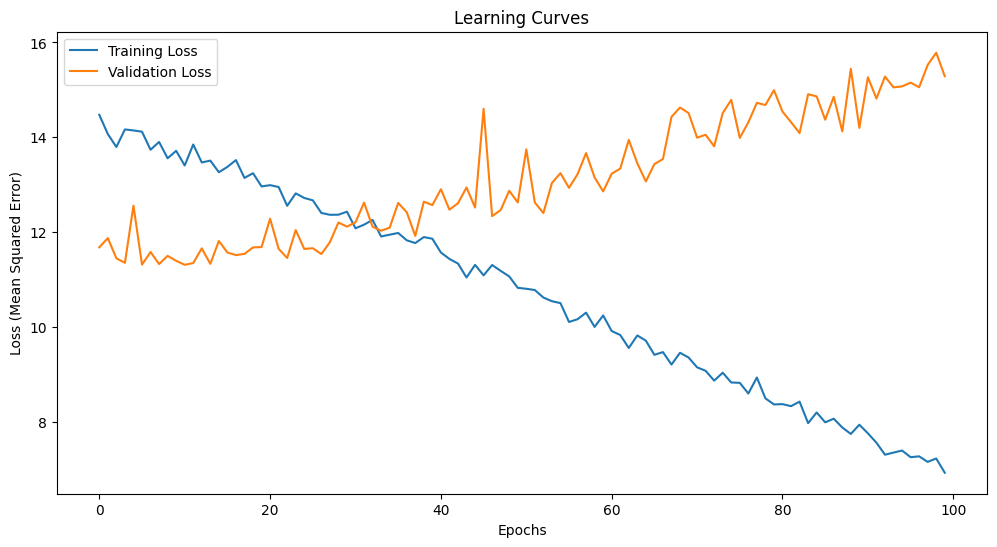

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape the predicted values and actual test values for comparison
y_test_pred = y_test_pred.flatten()  # Convert to 1D for easier plotting

# Visualize the distribution of actual vs predicted values using kdeplot
plt.figure(figsize=(12, 6))

# Distribution of actual values
sns.kdeplot(y_test_reshaped, color='blue', label='Actual Values', fill=True)

# Distribution of predicted values
sns.kdeplot(y_test_pred, color='orange', label='Predicted Values', fill=True)

plt.title('Distribution of Actual vs Predicted PM Values')
plt.xlabel('PM Values')
plt.ylabel('Density')
plt.legend()
plt.show()


# Line plot for Actual vs Predicted PM values for a subset of data
plt.figure(figsize=(12, 6))
plt.plot(y_test_reshaped[:100], color='blue', label='Actual PM Values')
plt.plot(y_test_pred[:100], color='orange', label='Predicted PM Values', linestyle='--')
plt.title('Actual vs Predicted PM Values (Subset of Test Data)')
plt.xlabel('Time Steps')
plt.ylabel('PM Values')
plt.legend()
plt.show()

# Learning Curves
history = model.fit(X_train_reshaped, y_train_reshaped, epochs=100, validation_data=(X_val_reshaped, y_val_reshaped), batch_size=64, verbose=0)

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.show()



# **Fine Tuning**

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.regularizers import l2


# Build the LSTM model with improvements
model = Sequential()

# Add Input layer (with timesteps and features)
model.add(Input(shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))

# Add LSTM layers with fewer units (reduce model complexity) and regularization
model.add(LSTM(50, return_sequences=True, kernel_regularizer=l2(0.005)))  # Add L2 regularization
model.add(Dropout(0.4))  # Increase dropout to 0.4

# Add a second LSTM layer if necessary
model.add(LSTM(25, kernel_regularizer=l2(0.0001)))  # Reduced units and L2 regularization
model.add(Dropout(0.5))  # Dropout after second LSTM layer

# Add Dense output layer (predicting a single value, such as PM2.5 or PM10)
model.add(Dense(1))

# Compile the model with Adam optimizer
opt = Adam(learning_rate=0.001)
model.compile(optimizer=opt, loss='mean_squared_error', metrics=['mae'])

# Add EarlyStopping to prevent overfitting, with higher patience
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train the model using the reshaped data
history = model.fit(X_train_reshaped, y_train_reshaped, epochs=100, batch_size=64, validation_data=(X_val_reshaped, y_val_reshaped), callbacks=[early_stopping])

# Evaluate the model on the test set
y_test_pred = model.predict(X_test_reshaped)

# Calculate evaluation metrics
test_mse = mean_squared_error(y_test_reshaped, y_test_pred)
test_mae = mean_absolute_error(y_test_reshaped, y_test_pred)

print(f'Test Mean Squared Error: {test_mse}')
print(f'Test Mean Absolute Error: {test_mae}')


Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 404.0453 - mae: 18.3685 - val_loss: 187.3274 - val_mae: 11.6673
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 168.0731 - mae: 10.6721 - val_loss: 104.9708 - val_mae: 7.9201
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 103.6557 - mae: 7.7888 - val_loss: 70.9245 - val_mae: 6.2961
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 81.5300 - mae: 6.8100 - val_loss: 58.7906 - val_mae: 5.7660
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 73.3310 - mae: 6.5421 - val_loss: 54.8983 - val_mae: 5.6392
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 71.9100 - mae: 6.5318 - val_loss: 53.6833 - val_mae: 5.6175
Epoch 7/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 72.0665 - mae: 6.5438 - val_loss: 53.3527 - val_mae: 5.6140
Epoch 8/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 74.4390 - mae: 6.5640 - val_loss: 53.1625 - val_mae: 5.6134
Epoch 9/100
211/211 

# **Evaluation**

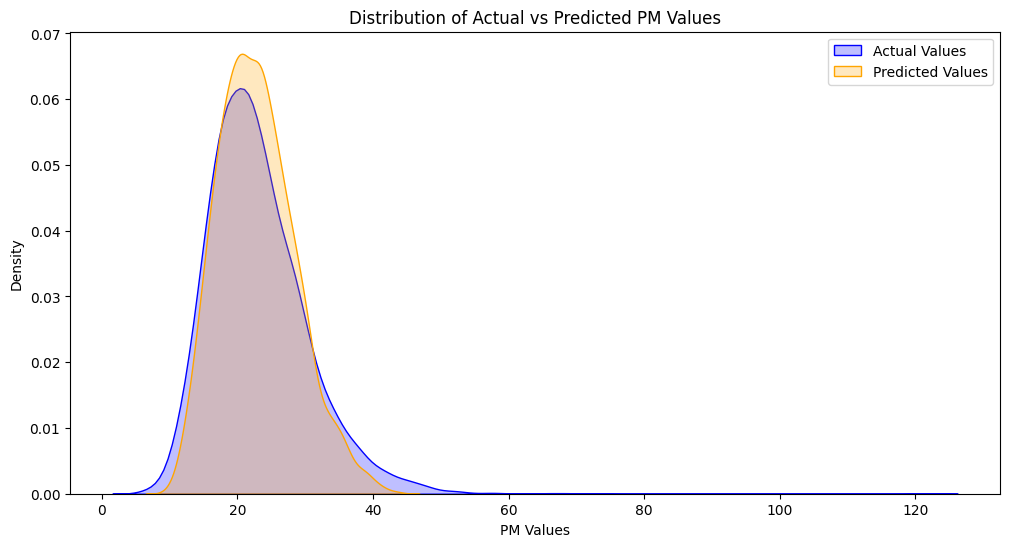

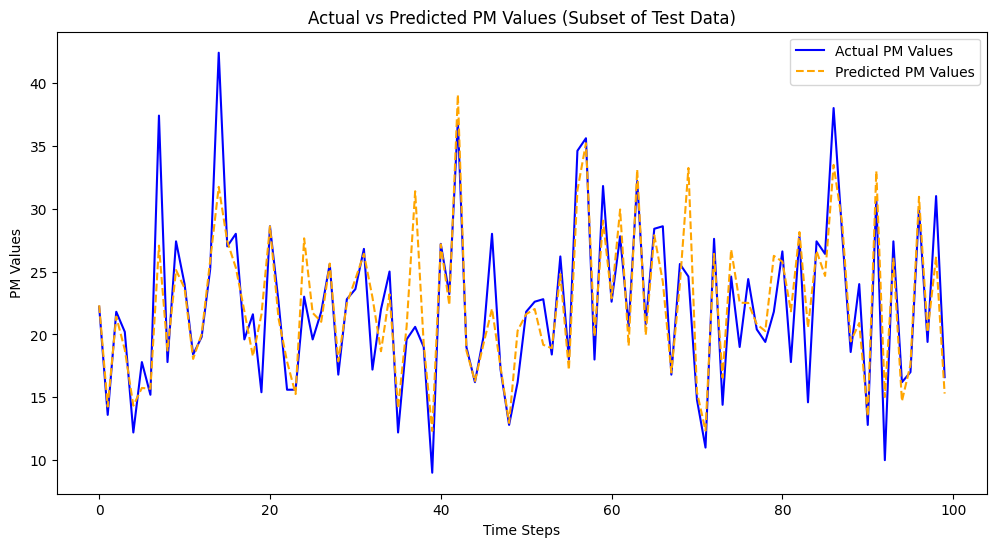

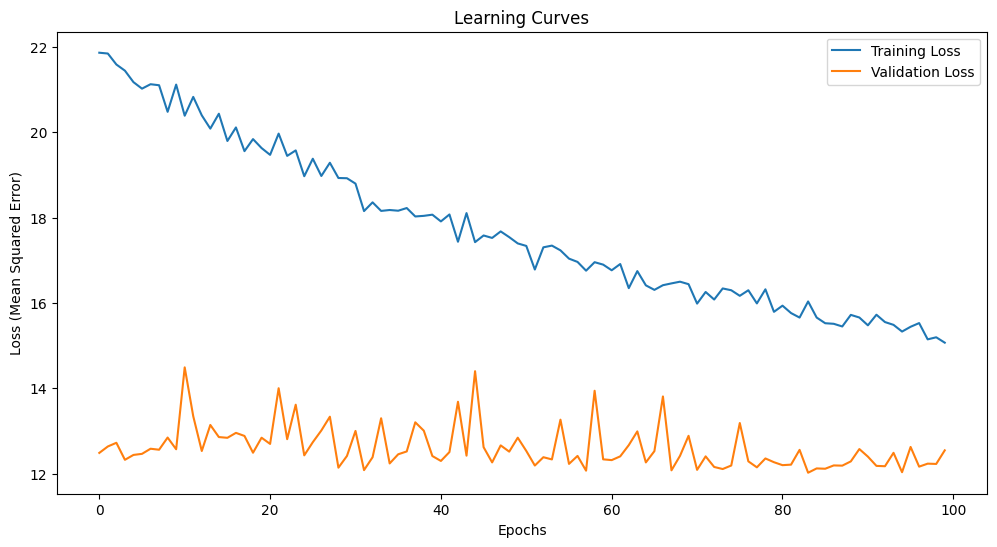

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape the predicted values and actual test values for comparison
y_test_pred = y_test_pred.flatten()  # Convert to 1D for easier plotting

# Visualize the distribution of actual vs predicted values using kdeplot
plt.figure(figsize=(12, 6))

# Distribution of actual values
sns.kdeplot(y_test_reshaped, color='blue', label='Actual Values', fill=True)

# Distribution of predicted values
sns.kdeplot(y_test_pred, color='orange', label='Predicted Values', fill=True)

plt.title('Distribution of Actual vs Predicted PM Values')
plt.xlabel('PM Values')
plt.ylabel('Density')
plt.legend()
plt.show()



# Line plot for Actual vs Predicted PM values for a subset of data
plt.figure(figsize=(12, 6))
plt.plot(y_test_reshaped[:100], color='blue', label='Actual PM Values')
plt.plot(y_test_pred[:100], color='orange', label='Predicted PM Values', linestyle='--')
plt.title('Actual vs Predicted PM Values (Subset of Test Data)')
plt.xlabel('Time Steps')
plt.ylabel('PM Values')
plt.legend()
plt.show()

# Learning Curves
history = model.fit(X_train_reshaped, y_train_reshaped, epochs=100, validation_data=(X_val_reshaped, y_val_reshaped), batch_size=64, verbose=0)

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.show()